<a href="https://colab.research.google.com/github/lnghan/MC311-Analysis/blob/main/2-eda/notebooks/le_capstone_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Han Le
# DATA 205 Project EDA Part



---



In [2]:
# Upload cleaned datasets (MC311 + Weather, ZIP Code)

from google.colab import files
uploaded = files.upload()

Saving zip_codes_clean.csv to zip_codes_clean.csv
Saving mc311_weather_clean.csv to mc311_weather_clean.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# Create a folder to save the graphs in

import os
os.makedirs("graphs", exist_ok=True)

In [5]:
mc311 = pd.read_csv('mc311_weather_clean.csv')
zips = pd.read_csv('zip_codes_clean.csv')

In [6]:
mc311.head()

,id,date_opened,date_closed,status,response_time,sla_days,within_sla,zip_code,city_name,department,area,area_topic,date,prcp,max_temp,min_temp,avg_temp,day_of_week,month
0,1583125970,2025-01-01,2025-01-07,Closed,6.0,60.0,Yes,20904,Colesville,DHCA,Code Enforcement,Housing Complaints,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
1,1583126482,2025-01-01,2025-01-15,Closed,14.0,3.0,No,20853,Rockville,DOT,Highway Services,Pothole Repair,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
2,1583126709,2025-01-01,2025-01-14,Closed,13.0,3.0,No,20904,Colesville,DOT,Highway Services,Pothole Repair,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
3,1583126729,2025-01-01,2025-01-02,Closed,1.0,3.0,Yes,20866,Burtonsville,DOT,Highway Services,Pothole Repair,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
4,1583154935,2025-01-02,2025-01-07,Closed,5.0,5.0,Yes,20833,Brookeville,DOT,Highway Services,Roadway Resurfacing or Repaving,2025-01-02,0.0,42.0,37.0,39.5,Thursday,January


In [7]:
zips.head()

,zip_code,med_household_income,med_individual_income,percent_under_18,population,housing_units,white,black,american_indian,asian,native_hawaiian,non_hispanic_other,hispanic,population_65_plus,med_age,city_name
0,20853,159080,54311,19.3,29673,10035,15086,3188,67,3508,10,130,7115,4706,41.4,Rockville
1,20866,140308,53463,31.9,13344,4652,3483,5703,30,2402,6,59,1287,1022,36.5,Burtonsville
2,20906,97521,45025,34.0,64696,25715,20713,15799,112,7489,32,452,18687,12445,40.1,Eastern Silver Spring
3,20833,204375,72026,12.2,7735,2545,5624,687,6,678,0,30,521,777,42.5,Brookeville
4,20904,96025,48018,35.7,54612,21452,14560,22696,81,7533,34,216,8061,8192,38.0,Colesville


In [8]:
merged = pd.merge(mc311, zips, on='city_name', how='left')

# Remove duplicate zip_code column
merged = merged.drop(columns=['zip_code_y'])
merged = merged.rename(columns={'zip_code_x': 'zip_code'})

merged.head()

,id,date_opened,date_closed,status,response_time,sla_days,within_sla,zip_code,city_name,department,...,housing_units,white,black,american_indian,asian,native_hawaiian,non_hispanic_other,hispanic,population_65_plus,med_age
0,1583125970,2025-01-01,2025-01-07,Closed,6.0,60.0,Yes,20904,Colesville,DHCA,...,21452,14560,22696,81,7533,34,216,8061,8192,38.0
1,1583126482,2025-01-01,2025-01-15,Closed,14.0,3.0,No,20853,Rockville,DOT,...,10035,15086,3188,67,3508,10,130,7115,4706,41.4
2,1583126709,2025-01-01,2025-01-14,Closed,13.0,3.0,No,20904,Colesville,DOT,...,21452,14560,22696,81,7533,34,216,8061,8192,38.0
3,1583126729,2025-01-01,2025-01-02,Closed,1.0,3.0,Yes,20866,Burtonsville,DOT,...,4652,3483,5703,30,2402,6,59,1287,1022,36.5
4,1583154935,2025-01-02,2025-01-07,Closed,5.0,5.0,Yes,20833,Brookeville,DOT,...,2545,5624,687,6,678,0,30,521,777,42.5




---



##**Exploring proportions with a focus on the cities**

In [9]:
# Make palette so each city has a consistent color when graphing

city_colors = {'Eastern Silver Spring': '#71DEAF',
               'Colesville': '#A971DE',
               'Rockville': '#D93434',
               'Burtonsville': '#FF82C6',
               'Brookeville': '#5EA9FF'}

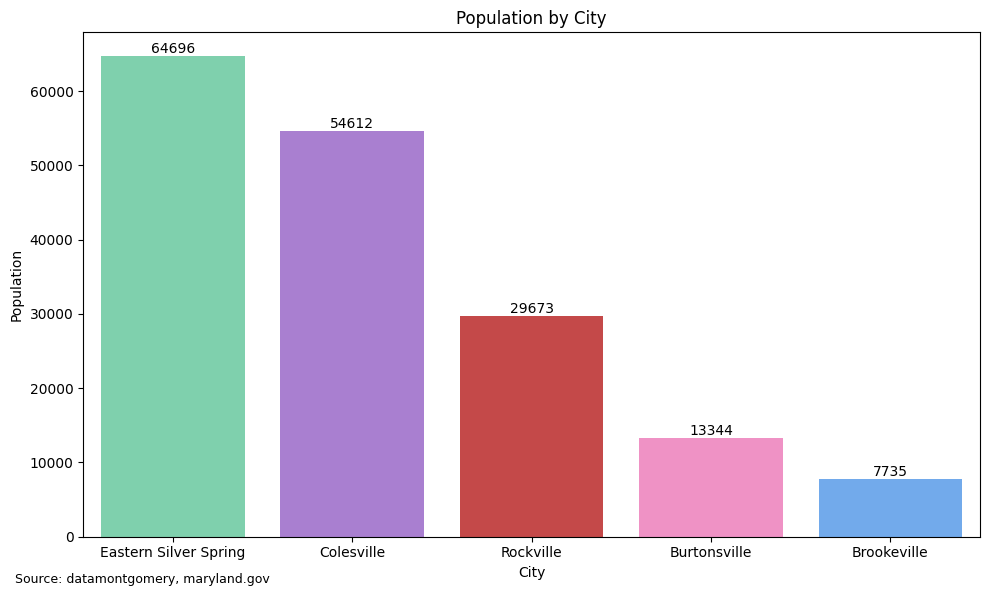

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=zips,
            x='city_name',
            order=['Eastern Silver Spring',
                   'Colesville',
                   'Rockville',
                   'Burtonsville',
                   'Brookeville'],
            y='population',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title('Population by City')
plt.xlabel('City')
plt.ylabel('Population')

# Put exact population for more detail
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.figtext(0.02, 0.02, "Source: datamontgomery, maryland.gov", fontsize=9, ha='left')
plt.tight_layout()
plt.savefig("graphs/population_by_city.png", bbox_inches="tight")
plt.show()

Eastern Silver Spring has the highest population and Brookeville has the lowest. There is a wide range in terms of population size.

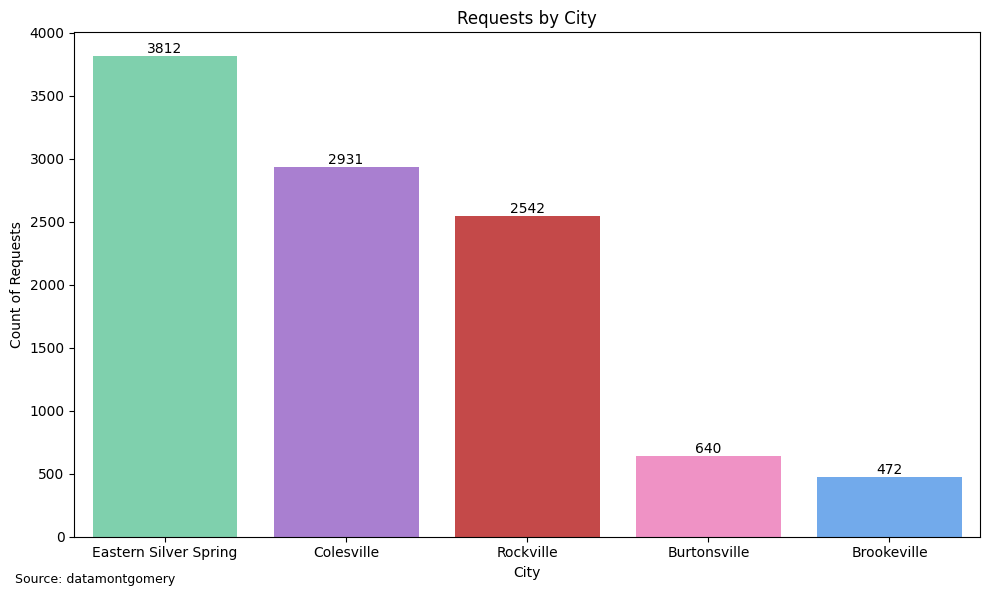

In [11]:
city_counts = mc311['city_name'].value_counts().reset_index()
city_counts.columns = ['city_name', 'count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_counts,
            x='city_name',
            y='count',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title("Requests by City")
plt.xlabel('City')
plt.ylabel('Count of Requests')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.figtext(0.02, 0.02, "Source: datamontgomery", fontsize=9, ha='left')
plt.tight_layout()
plt.savefig("graphs/requests_by_city.png", bbox_inches="tight")
plt.show()

This graph is on how many requests were made by city, the proportions for all the cities look very similar to the proportions in the population by city, EXCEPT Rockville, which has a visibly larger bar than it does in population.

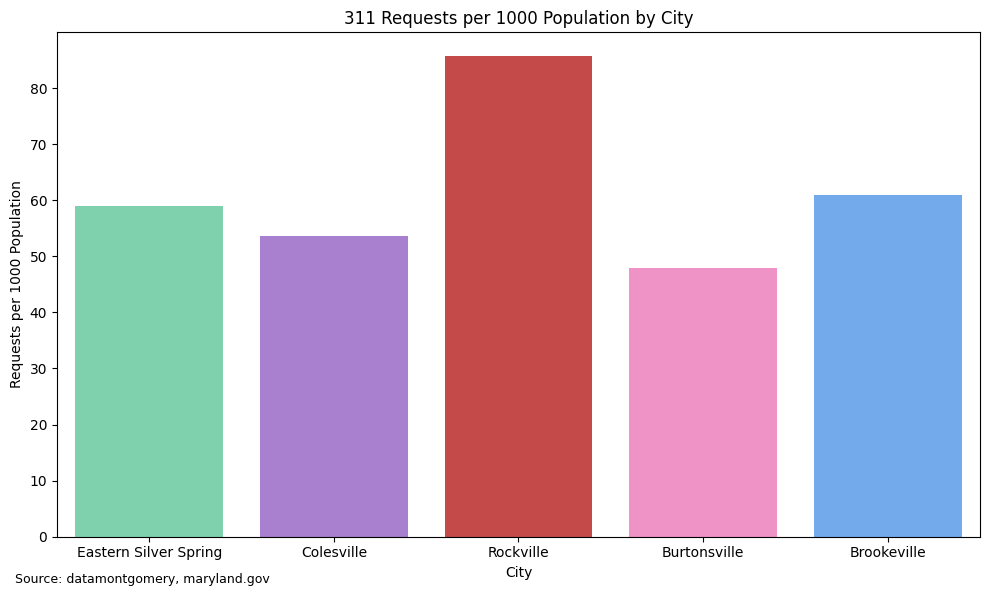

In [12]:
# Group by city_name and count the number of requests
request_counts = merged.groupby('city_name').size().reset_index(name='request_count')

# Get the population and merge with request counts
city_population = merged[['city_name', 'population']].drop_duplicates()
requests_and_population = pd.merge(request_counts, city_population, on='city_name', how='left')

# Calculate requests per capita
requests_and_population['requests_per_capita'] = (requests_and_population['request_count'] / requests_and_population['population']) * 1000

plt.figure(figsize=(10, 6))
sns.barplot(data=requests_and_population,
            x='city_name',
            order=['Eastern Silver Spring',
                   'Colesville',
                   'Rockville',
                   'Burtonsville',
                   'Brookeville'],
            y='requests_per_capita',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title('311 Requests per 1000 Population by City')
plt.xlabel('City')
plt.ylabel('Requests per 1000 Population')
plt.figtext(0.02, 0.02, "Source: datamontgomery, maryland.gov", fontsize=9, ha='left')
plt.tight_layout()
plt.savefig("graphs/requests_per_capita_by_city.png", bbox_inches="tight")
plt.show()

##Same thing as above but with plotly and colored by service area

In [13]:
# Group by city_name and area, and count
area_city_counts = merged.groupby(['city_name', 'area']).size().reset_index(name='count')

# Get population column
area_city_counts = pd.merge(area_city_counts, city_population, on='city_name', how='left')

# Requests per 1000 people and total per city
area_city_counts['per_capita'] = area_city_counts['count'] / area_city_counts['population'] * 1000
area_city_counts['city_total'] = area_city_counts.groupby('city_name')['per_capita'].transform('sum')

# Percentage
area_city_counts['percentage'] = area_city_counts['per_capita'] / area_city_counts['city_total'] * 100
area_city_counts['label'] = area_city_counts['percentage'].round(2).astype(str) + '%'

fig = px.bar(area_city_counts,
             x='city_name',
             y='per_capita',
             color='area',
             text='label',
             title='Requests per 1000 Population by City, Colored by Service Area',
             labels={'per_capita': 'Requests per 1000 Population',
                      'city_name': 'City'},
             category_orders={'city_name': ['Eastern Silver Spring',
                                            'Colesville',
                                            'Rockville',
                                            'Burtonsville',
                                            'Brookeville']},
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_layout(barmode='stack')
fig.add_annotation(
    text="Source: datamontgomery, maryland.gov",
    xref="paper", yref="paper",
    x=0, y=-0.15,  # Position at the bottom left
    showarrow=False,
    xanchor="left", yanchor="top",
    font=dict(size=10)
)
plt.savefig("graphs/requests_per_capita_plotly.png", bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

Highway services is the most requested service for all cities, but Rockville and Brookeville have a higher percentage of their requests being toward highway services compared to the other 3 cities.

##**Exploring Response Time and SLA Variables**

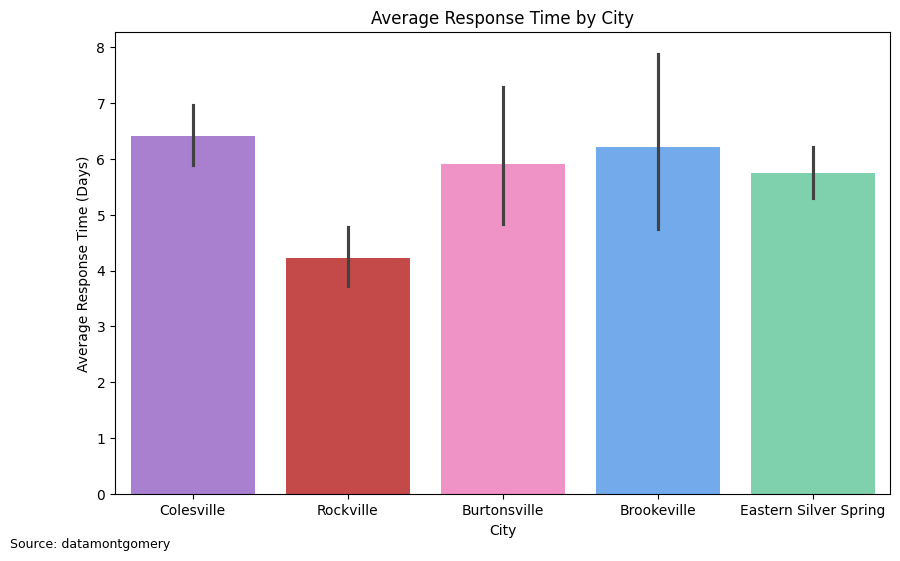

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data=mc311,
            x='city_name',
            y='response_time',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title('Average Response Time by City')
plt.xlabel('City')
plt.ylabel('Average Response Time (Days)')
plt.figtext(0.02, 0.02, "Source: datamontgomery", fontsize=9, ha='left')
plt.savefig("graphs/avg_response_time_city.png", bbox_inches="tight")
plt.show()

Rockville has quickest average response time of 4 with an error range of ~1 day. Meanwhile Brookville's average response time is 6 days with the biggest error range than the other cities.

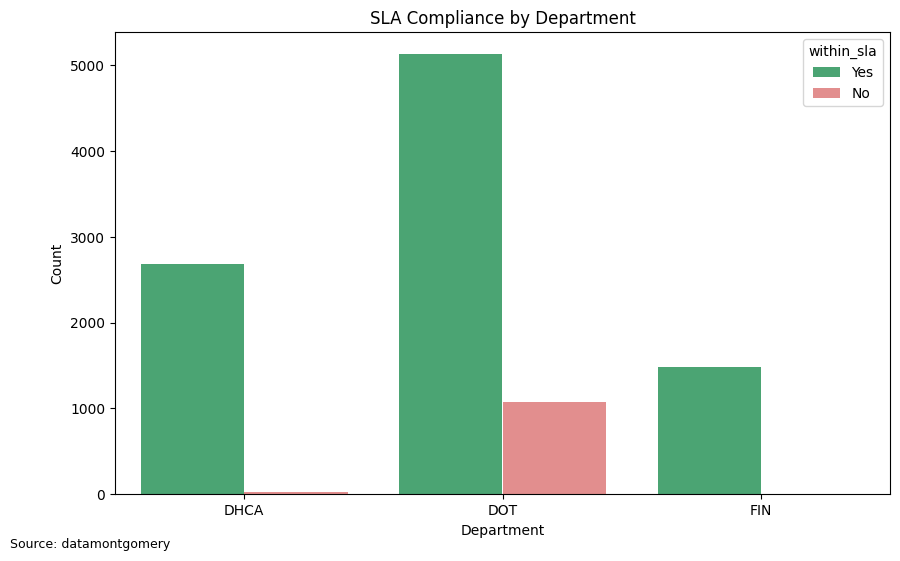

In [15]:
dept_counts = mc311['department'].value_counts().index

plt.figure(figsize=(10,6))
sns.countplot(data=mc311[mc311['department'].isin(dept_counts)],
              x='department',
              hue='within_sla',
              palette={'Yes': 'mediumseagreen',
                       'No': 'lightcoral'})
plt.title('SLA Compliance by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.figtext(0.02, 0.02, "Source: datamontgomery", fontsize=9, ha='left')
plt.savefig("graphs/sla_compliance.png", bbox_inches="tight")
plt.show()

Department of Transportation has a visible number of cases not being in within SLA compliance days. Department of Housing and Community Affairs and Finance Department do not have visible bars to indicate "No", but could be due to DOT having much more cases than the other two departments.

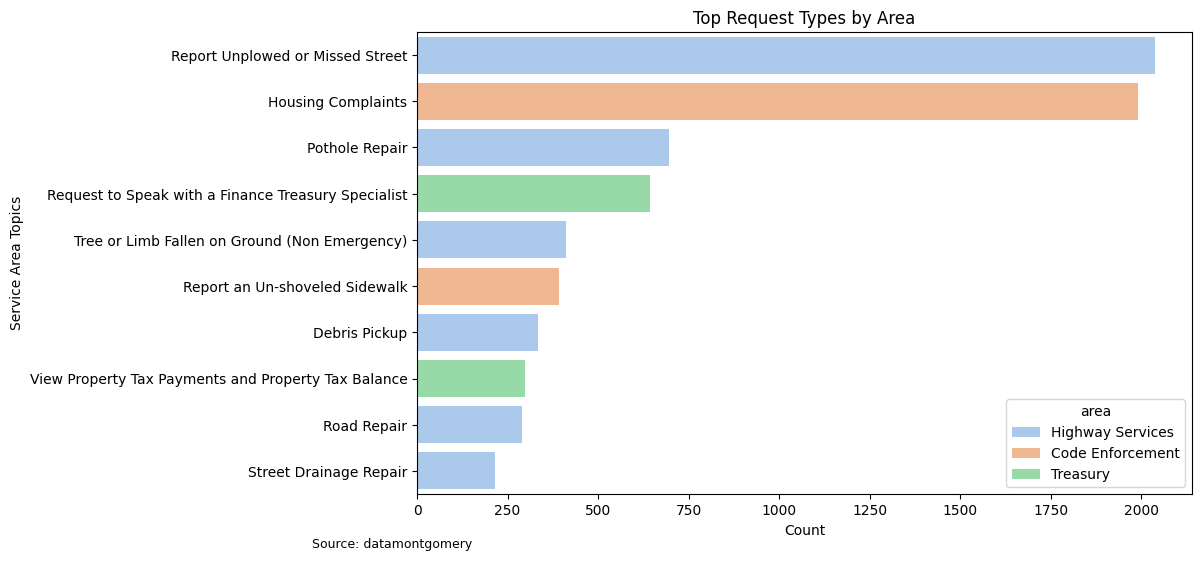

In [16]:
# Find top 10 most requested topics and its counts
topic_count = mc311['area_topic'].value_counts().head(10).reset_index()
topic_count.columns = ['area_topic', 'count']

# Get the corresponding 'area' for each 'area_topic' for bar coloring, and merge
area_topic = mc311[['area_topic', 'area']]
topic_area_count = pd.merge(topic_count, area_topic, on='area_topic', how='left')

plt.figure(figsize=(10, 6))
sns.barplot(data=topic_area_count,
            x='count',
            y='area_topic',
            hue='area',
            palette='pastel')
plt.title("Top Request Types by Area")
plt.xlabel('Count')
plt.ylabel('Service Area Topics')
plt.figtext(0.02, 0.02, "Source: datamontgomery", fontsize=9, ha='left')
plt.savefig("graphs/top_request_types.png", bbox_inches="tight")
plt.show()

Lots of unplowed/missed street (most likely due to snowstorm), but housing complaints is very close.

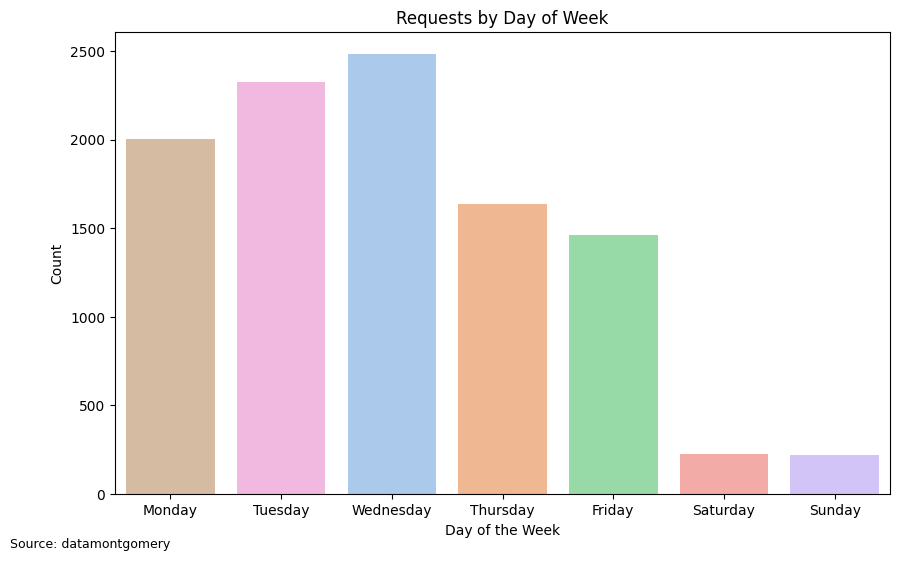

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=mc311,
              x='day_of_week',
              order=['Monday',
                     'Tuesday',
                     'Wednesday',
                     'Thursday',
                     'Friday',
                     'Saturday',
                     'Sunday'],
              hue='day_of_week',
              palette='pastel',
              legend=False)
plt.title("Requests by Day of Week")
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.figtext(0.02, 0.02, "Source: datamontgomery", fontsize=9, ha='left')
plt.savefig("graphs/requests_day_of_week.png", bbox_inches="tight")
plt.show()

MC311 is not busy on the weekends. The amount of requests hit a peak in the middle of the week (Wednesdays), and then gradually decreases, only to rise again when the week starts (Monday). Could be due to people working on weekdays more than weekends, so more people are out of their houses.

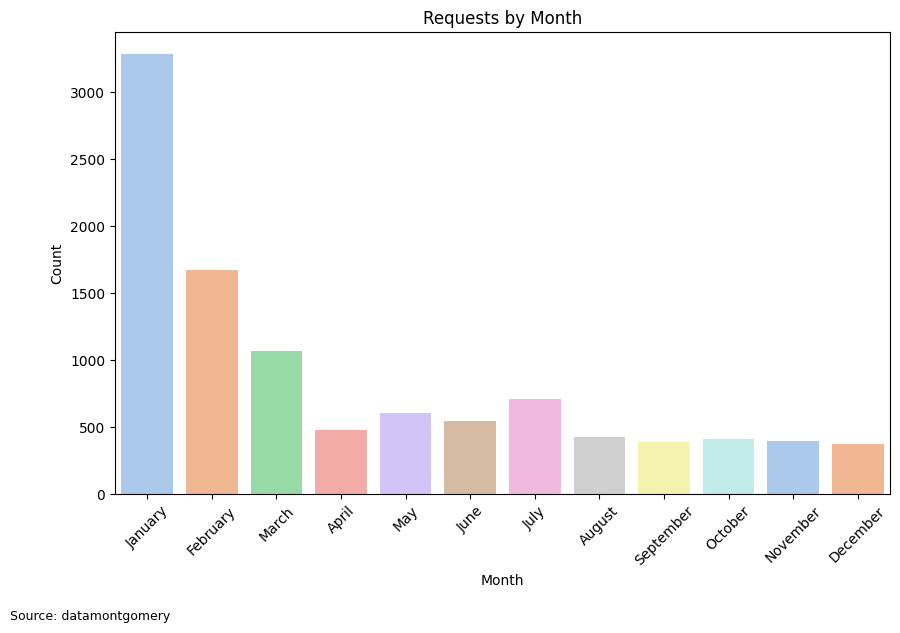

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=mc311,
              x='month',
              hue='month',
              palette='pastel',
              legend=False)
plt.title("Requests by Month")
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Count')
plt.figtext(0.02, -0.1, "Source: datamontgomery", fontsize=9, ha='left')
plt.savefig("graphs/requests_by_month.png", bbox_inches="tight")
plt.show()

Very big influx in January, most likely due to weather issues.

In [19]:
temp_counts = mc311.groupby('avg_temp').size().reset_index(name='count')

fig = px.line(temp_counts, x='avg_temp', y='count',
              title="Requests vs Temperature",
              labels={'avg_temp': 'Average Temperature (°F)',
                      'count': 'Number of Requests'})
fig.add_annotation(
    text="Source: datamontgomery, NOAA",
    xref="paper", yref="paper",
    x=0, y=-0.15,  # Position at the bottom left
    showarrow=False,
    xanchor="left", yanchor="top",
    font=dict(size=10)
)
plt.savefig("graphs/req_temp.png", bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

Highest peaks of requests in cold temperatures, many smaller peaks as temperature increases but no clear pattern to the peaks.